# 🚗 차량 Instance Segmentation 파인튜닝 · 평가 노트북

**프로젝트**: Segmentation 기반 도로 CCTV의 도로 대비 차량 면적 비를 활용한 교통 혼잡도 측정 시스템
**이 노트북이 하는 일**: YOLO 세그멘테이션 모델 1개를
**학습 → 평가(mAP) → 조건별 성능(주/야간·날씨·도로) → 추론 시간 → 차량 면적 비 오차 → 실험 기록표(CSV)에 한 줄 추가**

---

### 폴더 구조 (6명 모두 똑같이)
```
traffic_data2/
├── car_seg_finetune.ipynb     ← 이 노트북
├── car_seg_split/             ← 데이터셋 (train 2,500 / val 1,000 / test 5,000)
└── car_seg_finetune/          ← 실행하면 자동으로 생김
    ├── weights/               사전학습 가중치 (자동 다운로드)
    ├── runs/<실험이름>/        학습 결과 · 평가 그래프 · summary.json
    └── results/<이름>_experiments.csv   ★ 실험 기록표
```

### 사용법 (3단계)
1. **`1. 실험 설정` 셀만 수정**합니다. (이름, 모델, 하이퍼파라미터)
2. 처음에는 `QUICK_TEST = True` 로 **Run All** → 끝까지 에러 없이 도는지 확인 (약 5분)
3. `QUICK_TEST = False` 로 바꾸고 다시 **Run All** → 본 실험

> 실험할 때마다 설정만 바꾸고 Run All 하면 기록표에 **한 줄씩 쌓입니다**.
> 6명의 CSV 를 `car_seg_finetune/results/` 에 모으면 마지막 셀에서 **전체 비교표**가 나옵니다.

### 6명 모델 분담 (예시)
| 담당 | 모델 | 설명 |
|---|---|---|
| 1번 | `yolo26n-seg` | 최신(2026) · nano |
| 2번 | `yolo26s-seg` | 최신(2026) · small |
| 3번 | `yolo11n-seg` | 2024 · nano |
| 4번 | `yolo11s-seg` | 2024 · small |
| 5번 | `yolov8n-seg` | 2023 · nano |
| 6번 | `yolov8s-seg` | 2023 · small |

### 데이터셋 특징 (`car_seg_split/README.md`)
- **train 은 어려운 이미지 위주** (야간·악천후·교량/터널 등 hard 89%), **val · test 는 실제 분포 그대로** (hard 67%)
- val · test 모두 **CCTV 49대 전부** 포함 → 새로운 구도에서도 잘 되는지 공정하게 평가
- bus 가 매우 적음 (train 객체의 5%) → bus AP 가 낮게 나오기 쉬움

### 추천 실험 순서
1. **Baseline** — 6명 모두 *같은 설정*(기본값 그대로)으로 1회 → 모델끼리 공정 비교
2. **각자 튜닝** — 한 번에 **한 가지만** 바꾸고 `MEMO` 에 적기 (예: `imgsz 640→1280`, `lr0 1e-3→5e-4`, `copy_paste 0→0.3`, `cls_pw 0→0.5`)
3. **설정은 val 점수로 고르기** — test 점수는 기록만 하고, 보고 고르지 않기 (test 에 과적합 방지)
4. train 이 2,500장으로 작아서 **같은 설정도 SEED 에 따라 mAP 가 ±0.01 정도 흔들릴 수 있음** → 차이가 작으면 SEED 를 바꿔 한 번 더 확인

### ⚠️ 맥북에서 오래 학습할 때
- **전원 어댑터 연결**, 저전력 모드 끄기, **뚜껑 닫지 않기** (노트북이 자동으로 잠자기 방지 `caffeinate` 를 켭니다)
- 추론 시간 측정 중에는 **다른 앱을 끄세요** (6명 결과를 공정하게 비교하기 위해)

## 0. 설치 & 환경 확인
처음 한 번만 설치하면 됩니다. **6명 모두 같은 버전**을 써야 결과를 비교할 수 있어서 버전을 고정했습니다.

In [1]:
%pip install -q "ultralytics==8.4.152" pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # MPS(맥 GPU)가 지원 안 하는 연산은 자동으로 CPU 로 처리

import gc, json, platform, random, subprocess, time, warnings
from datetime import datetime
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
import ultralytics
from ultralytics import YOLO
from PIL import Image

# 한글 폰트 (맥 기본 폰트)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 맥 GPU 에서 매 step 마다 뜨는 "deterministic 미지원" 경고 숨기기 (학습에는 영향 없음)
warnings.filterwarnings("ignore", message=".*does not have a deterministic implementation.*")

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

def chip_name():
    try:
        return subprocess.check_output(["sysctl", "-n", "machdep.cpu.brand_string"], text=True).strip()
    except Exception:
        return platform.processor()

def ram_gb():
    try:
        return round(int(subprocess.check_output(["sysctl", "-n", "hw.memsize"], text=True)) / 2**30)
    except Exception:
        return None

def free_memory():
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()

print(f"Python      : {platform.python_version()}")
print(f"PyTorch     : {torch.__version__}")
print(f"Ultralytics : {ultralytics.__version__}")
print(f"칩 / 메모리  : {chip_name()} / {ram_gb()} GB")
print(f"학습 장치    : {DEVICE}")
if DEVICE != "mps":
    print("⚠️ MPS(맥 GPU)를 찾지 못했습니다. CPU 로 돌면 매우 느립니다.")

# 노트북이 켜져 있는 동안 맥이 잠들지 않게 함 (노트북 커널이 꺼지면 자동 해제)
if platform.system() == "Darwin":
    subprocess.Popen(["caffeinate", "-dims", "-w", str(os.getpid())])
    print("☕ 잠자기 방지(caffeinate) 켜짐")

Python      : 3.11.15
PyTorch     : 2.14.0
Ultralytics : 8.4.152
칩 / 메모리  : Apple M5 / 24 GB
학습 장치    : mps
☕ 잠자기 방지(caffeinate) 켜짐


## 1. ★ 실험 설정 — 여기만 바꾸세요 ★
- 값 옆의 주석에 **무엇을 하는지**를 적어두었습니다.
- 모든 이름은 Ultralytics 공식 인자 이름과 같습니다 → 궁금하면 [공식 문서](https://docs.ultralytics.com/usage/cfg/)에서 검색

In [19]:
# ============================================================================
# (A) 누가 · 어떤 모델로 · 무엇을 바꿨나
# ============================================================================
MEMBER = "한태호"          # 내 이름 → 결과표 · 폴더 이름에 들어감
MODEL  = "yolov8s-seg"     # "yolo26n-seg" "yolo26s-seg" "yolo11n-seg" "yolo11s-seg" "yolov8n-seg" "yolov8s-seg"
MEMO   = "baseline (기본 설정)"   # 이번 실험에서 바꾼 점 한 줄 (결과표 '메모' 칸)

QUICK_TEST = True          # True: train 300장·3 epoch 로 "코드가 끝까지 도는지"만 확인 / False: 본 실험

# ============================================================================
# (B) 학습 기본
# ============================================================================
EPOCHS     = 50            # 최대 학습 횟수 (PATIENCE 때문에 그 전에 멈출 수 있음)
PATIENCE   = 15            # val 성능이 N epoch 동안 안 좋아지면 조기 종료
TIME_HOURS = None          # 최대 학습 시간(시간). 예: 8 → 8시간 되면 멈춤 (EPOCHS 보다 우선). None = 제한 없음
IMGSZ      = 640           # 입력 크기. 차량 대부분이 작은 객체라 크게 할수록 정확↑ 속도↓ (640 / 960 / 1280)
BATCH      = 8             # 메모리 부족 에러가 나면 줄이기 (아래 표 참고)
SEED       = 42            # 랜덤 시드. 같은 설정인데 결과 차이가 작을 땐 바꿔서 한 번 더
PRETRAINED = True          # True: COCO 사전학습 가중치에서 시작(파인튜닝) / False: 처음부터
FREEZE     = None          # 앞쪽 N개 층을 얼림(학습 안 함). None=전부 학습, 10=backbone 얼림 → 빠르지만 정확도↓ 가능
#   📌 참고: M5(24GB) 실측 · train 2,500장 1 epoch 시간 (검증 약 1분 별도) · 메모리 사용량
#      imgsz  640 · batch 8 : n ≈ 5분 / s ≈ 9분              (메모리 약 5GB)
#      imgsz  960 · batch 8 : s ≈ 18분                         (메모리 약 12GB → 16GB 맥이면 batch 4)
#      imgsz 1280 · batch 4 : n ≈ 15분 / s ≈ 22~28분           (메모리 약 6~11GB)
#   → 50 epoch 이면 640 은 반나절, 1280 은 하루 이상. 오래 걸리면 TIME_HOURS 로 상한을 거세요.
# ============================================================================
# (C) 옵티마이저 · 학습률
#   ⚠️ OPTIMIZER="auto" 로 두면 Ultralytics 가 LR0 · MOMENTUM 을 무시하고 자동 결정합니다.
#      학습률을 직접 실험하려면 "AdamW" 나 "SGD" 로 지정하세요.
# ============================================================================
OPTIMIZER     = "AdamW"    # "AdamW" "SGD" "MuSGD" "auto"
LR0           = 0.001      # 시작 학습률 (AdamW 보통 1e-3 ~ 1e-4 / SGD 보통 1e-2)
LRF           = 0.01       # 마지막 학습률 = LR0 × LRF
COS_LR        = False      # True: cosine 스케줄 / False: 선형 감소
MOMENTUM      = 0.937      # SGD momentum (Adam 계열은 beta1)
WEIGHT_DECAY  = 0.0005     # 과적합 방지 (L2)
WARMUP_EPOCHS = 3          # 처음 N epoch 동안 학습률을 서서히 올림
WARMUP_BIAS_LR = 0.1 if OPTIMIZER == "SGD" else 0.0   # 워밍업 때 bias 학습률. Adam 계열에서 0.1 이면 학습이 망가질 수 있어 0

# ============================================================================
# (D) 손실 가중치 (Loss gain)
# ============================================================================
LOSS = dict(
    box    = 7.5,    # 박스 위치 손실 가중치
    cls    = 0.5,    # 클래스 분류 손실 가중치
    dfl    = 1.5,    # 박스 경계 분포 손실 (YOLO26 은 DFL 이 없어서 L1 손실 가중치로 쓰임)
    cls_pw = 0.0,    # 클래스 불균형 보정 (0=끔, 1=빈도 역수로 강하게). bus 가 적어서 0.3~1.0 시도해볼 만함
)

# ============================================================================
# (E) 데이터 증강 (Augmentation) — 0 이면 끔
# ============================================================================
AUGMENT = dict(
    hsv_h        = 0.015,  # 색조 변화
    hsv_s        = 0.7,    # 채도 변화
    hsv_v        = 0.4,    # 밝기 변화 (주/야간 대응)
    degrees      = 0.0,    # 회전 각도 ±
    translate    = 0.1,    # 이동 비율 ±
    scale        = 0.5,    # 확대/축소 비율 ±
    shear        = 0.0,    # 기울이기 각도 ±
    perspective  = 0.0,    # 원근 변형 (0 ~ 0.001)
    fliplr       = 0.5,    # 좌우 뒤집기 확률
    flipud       = 0.0,    # 상하 뒤집기 확률 (CCTV 는 위아래가 고정이라 보통 0)
    mosaic       = 1.0,    # 4장 이어붙이기 확률
    close_mosaic = 10,     # 마지막 N epoch 은 mosaic 끄기
    mixup        = 0.0,    # 2장 겹치기 확률
    copy_paste   = 0.0,    # 객체를 다른 이미지에 복사해 붙이기 비율 (작은 객체 · bus 부족에 도움될 수 있음)
)

# ============================================================================
# (F) 세그멘테이션 전용
# ============================================================================
SEG = dict(
    overlap_mask = True,   # 학습 시 인스턴스 마스크들을 한 장으로 합쳐서 처리 (메모리 절약)
    mask_ratio   = 4,      # 마스크 다운샘플 비율. 작을수록 마스크가 정밀하지만 느리고 메모리↑ (1, 2, 4)
)

# ============================================================================
# (G) 평가 · 추론
# ============================================================================
EVAL_TEST  = True          # True: test 셋(5,000장) 평가도 수행 → 기록만 하고, 설정은 val 점수로 고르기
EVAL_CONF  = 0.001         # mAP 계산용 confidence (mAP 는 낮게 두는 게 표준)
NMS_IOU    = 0.7           # NMS IoU 임계값 (겹친 박스 제거 기준)
MAX_DET    = 300           # 이미지당 최대 검출 수

EVAL_BY_CONDITION = True   # True: 주/야간 · 날씨 · 도로 형태별 mAP 도 계산 (평가 시간이 늘어남)
CONDITIONS = ["day_night", "weather", "road_form"]   # split_manifest.csv 의 컬럼 이름 (difficulty, time_band 등도 가능)
MIN_GROUP_IMAGES = 30      # 이미지가 이보다 적은 조건은 건너뜀 (점수가 불안정해서)

PRED_CONF    = 0.25        # 실제 사용(면적 비 계산 · 시각화)할 때의 confidence
SPEED_N      = 100         # 추론 시간 측정에 쓸 이미지 수
SPEED_WARMUP = 10          # 측정 전 워밍업 횟수 (첫 추론은 느려서 제외)
AREA_N       = 1000        # 차량 면적 비 오차를 계산할 이미지 수 (None = 전부)

# ============================================================================
# (H) 폴더 (보통 안 바꿔도 됨)
# ============================================================================
DATA_DIR = "car_seg_split"       # 데이터셋 폴더 (이 노트북과 같은 폴더에 있음)
WORK_DIR = "car_seg_finetune"    # 결과가 저장될 폴더

## 2. 설정 정리 & 데이터 준비
- `QUICK_TEST` 이면 값들을 작게 덮어씁니다.
- `car_seg_split/data.yaml` 에는 데이터를 만든 사람의 컴퓨터 경로가 적혀 있어서, **내 컴퓨터 경로로 고친 yaml** 을 실험 폴더에 새로 만듭니다.
- `split_manifest.csv` 에서 이미지별 조건(주/야간 · 날씨 · 도로 형태 …)을 읽어둡니다.

In [20]:
# ---- QUICK_TEST 면 작게 덮어쓰기 ----
if QUICK_TEST:
    EPOCHS, PATIENCE, TIME_HOURS, WARMUP_EPOCHS = 3, 3, None, 1
    SPEED_N, SPEED_WARMUP, AREA_N = 30, 5, 30
    print("🧪 QUICK_TEST 모드: train 300장 / val·test 100장 / 3 epoch — 점수는 참고용, 코드가 끝까지 도는지 확인")

# ---- 폴더 ----
DATA_ROOT   = Path(DATA_DIR).expanduser().resolve()
WORK_ROOT   = Path(WORK_DIR).expanduser().resolve()
WEIGHTS_DIR = WORK_ROOT / "weights"      # 사전학습 가중치
RUNS_DIR    = WORK_ROOT / "runs"         # 실험별 결과
RESULTS_DIR = WORK_ROOT / "results"      # 실험 기록표 CSV
for d in (WEIGHTS_DIR, RUNS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert (DATA_ROOT / "data.yaml").exists(), \
    f"❌ {DATA_ROOT}/data.yaml 이 없습니다. 노트북과 같은 폴더에 car_seg_split 이 있는지 확인하세요."

STAMP    = datetime.now().strftime("%Y%m%d-%H%M")
EXP_NAME = f"{MEMBER}_{MODEL}_img{IMGSZ}_{STAMP}" + ("_QUICK" if QUICK_TEST else "")
EXP_DIR  = RUNS_DIR / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)
print("실험 이름:", EXP_NAME)

# ---- 클래스 · 이미지 목록 ----
with open(DATA_ROOT / "data.yaml", encoding="utf-8") as f:
    CLASS_NAMES = yaml.safe_load(f)["names"]          # {0: 'car', 1: 'bus', 2: 'truck'}

def list_images(split):
    folder = DATA_ROOT / "images" / split
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}) if folder.exists() else []

def pick(images, count, seed=SEED):
    # SEED 로 무작위로 count 장 고르기 → 누가 돌려도 같은 이미지
    images = list(images)
    return images if count is None or count >= len(images) else sorted(random.Random(seed).sample(images, count))

ALL_IMAGES = {s: list_images(s) for s in ["train", "val", "test"]}
print("데이터셋:", {s: len(v) for s, v in ALL_IMAGES.items()})
if not ALL_IMAGES["test"] and EVAL_TEST:
    print("⚠️ test 폴더가 없어 test 평가는 건너뜁니다."); EVAL_TEST = False

if QUICK_TEST:
    train_imgs, val_imgs, test_imgs = pick(ALL_IMAGES["train"], 300), pick(ALL_IMAGES["val"], 100), pick(ALL_IMAGES["test"], 100)
else:
    train_imgs, val_imgs, test_imgs = ALL_IMAGES["train"], ALL_IMAGES["val"], ALL_IMAGES["test"]

# ---- 이미지별 조건 정보 (주/야간 · 날씨 · 도로 형태 …) ----
MANIFEST = pd.read_csv(DATA_ROOT / "split_manifest.csv", encoding="utf-8-sig", low_memory=False)
MANIFEST = MANIFEST[MANIFEST["split"].isin(["train", "val", "test"])].set_index("file_name")
CONDITIONS = [c for c in CONDITIONS if c in MANIFEST.columns]

# ---- 이미지 목록 txt + 내 컴퓨터용 data.yaml ----
LISTS_DIR = EXP_DIR / "lists"
LISTS_DIR.mkdir(exist_ok=True)

def write_list(name, images):
    path = LISTS_DIR / f"{name}.txt"
    path.write_text("\n".join(str(p) for p in images), encoding="utf-8")
    return str(path)

def write_data_yaml(path, train, val, test=None):
    with open(path, "w", encoding="utf-8") as f:
        yaml.safe_dump({"path": str(DATA_ROOT), "train": train, "val": val, "test": test, "names": CLASS_NAMES},
                       f, allow_unicode=True, sort_keys=False)
    return str(path)

DATA_YAML = write_data_yaml(EXP_DIR / "data.yaml",
                            write_list("train", train_imgs), write_list("val", val_imgs),
                            write_list("test", test_imgs) if test_imgs else None)

print(f"이번 실험 사용량 → train {len(train_imgs):,} / val {len(val_imgs):,} / test {len(test_imgs):,}")
split_info = pd.DataFrame({s: MANIFEST.loc[[p.name for p in imgs], "day_night"].value_counts()
                           for s, imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)] if imgs})
split_info

🧪 QUICK_TEST 모드: train 300장 / val·test 100장 / 3 epoch — 점수는 참고용, 코드가 끝까지 도는지 확인
실험 이름: 한태호_yolov8s-seg_img640_20260915-0853_QUICK
데이터셋: {'train': 2500, 'val': 1000, 'test': 5000}
이번 실험 사용량 → train 300 / val 100 / test 100


,train,val,test
day_night,,,
day,178,83,75
night,74,11,12
twilight,48,6,13


### 데이터 눈으로 확인
정답 폴리곤을 이미지 위에 그려봅니다. (car=파랑, bus=초록, truck=빨강)

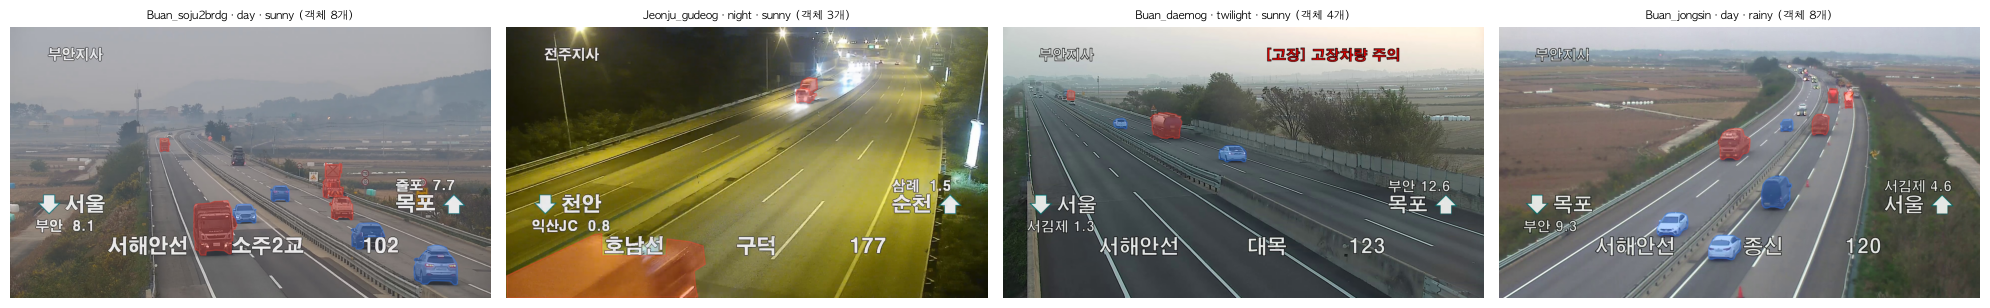

In [21]:
CLASS_COLORS = {0: (0.2, 0.5, 1.0), 1: (0.1, 0.8, 0.2), 2: (1.0, 0.25, 0.2)}   # car, bus, truck

def label_path_of(img_path):
    # .../car_seg_split/images/train/xxx.jpg → .../car_seg_split/labels/train/xxx.txt
    return Path(str(img_path).replace(f"{os.sep}images{os.sep}", f"{os.sep}labels{os.sep}")).with_suffix(".txt")

def read_polygons(img_path, w, h):
    # YOLO 라벨 → [(클래스, 픽셀 좌표 배열), ...]
    polys = []
    lp = label_path_of(img_path)
    if lp.exists():
        for line in lp.read_text().splitlines():
            v = line.split()
            if len(v) >= 7:
                polys.append((int(v[0]), np.array(v[1:], dtype=float).reshape(-1, 2) * [w, h]))
    return polys

def draw_gt(ax, img_path):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    polys = read_polygons(img_path, *img.size)
    for cls, xy in polys:
        ax.add_patch(plt.Polygon(xy, closed=True, fill=True, alpha=0.35,
                                 facecolor=CLASS_COLORS[cls], edgecolor=CLASS_COLORS[cls], linewidth=1))
    info = MANIFEST.loc[Path(img_path).name]
    ax.set_title(f"{info['camera']} · {info['day_night']} · {info['weather']} (객체 {len(polys)}개)", fontsize=8)
    ax.axis("off")

# 주간 / 야간 / 황혼 / 악천후 예시를 한 장씩
examples = []
for cond in [("day_night", "day"), ("day_night", "night"), ("day_night", "twilight"), ("weather", "rainy")]:
    names = [p for p in train_imgs if MANIFEST.loc[p.name, cond[0]] == cond[1]]
    if names:
        examples.append(pick(names, 1, seed=SEED + 1)[0])

fig, axes = plt.subplots(1, len(examples), figsize=(5 * len(examples), 4))
for ax, p in zip(np.atleast_1d(axes), examples):
    draw_gt(ax, p)
plt.tight_layout(); plt.show()

## 3. 학습
- 사전학습 가중치(`yolo11n-seg.pt` 등)는 처음 실행할 때 `car_seg_finetune/weights/` 에 자동으로 다운로드됩니다.
- 결과는 `car_seg_finetune/runs/<실험이름>/train/` 에 저장됩니다.
- **중간에 끊겼다면** 아래 `3-1. 이어서 학습` 셀을 쓰세요.

In [22]:
TRAIN_ARGS = dict(
    data=DATA_YAML, device=DEVICE,
    epochs=EPOCHS, time=TIME_HOURS, patience=PATIENCE,
    imgsz=IMGSZ, batch=BATCH, pretrained=PRETRAINED, freeze=FREEZE, seed=SEED,
    optimizer=OPTIMIZER, lr0=LR0, lrf=LRF, cos_lr=COS_LR,
    momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, warmup_epochs=WARMUP_EPOCHS, warmup_bias_lr=WARMUP_BIAS_LR,
    **LOSS, **AUGMENT, **SEG,
    iou=NMS_IOU, max_det=MAX_DET,
    project=str(EXP_DIR), name="train", exist_ok=True,
    cache=False, plots=True, verbose=True,
)

# 설정을 파일로 저장 (나중에 "그때 뭘로 돌렸지?" 확인용)
with open(EXP_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump({"MEMBER": MEMBER, "MODEL": MODEL, "MEMO": MEMO, "QUICK_TEST": QUICK_TEST, **TRAIN_ARGS},
              f, ensure_ascii=False, indent=2)

pd.DataFrame(TRAIN_ARGS.items(), columns=["인자", "값"]).set_index("인자").T

인자,data,device,epochs,time,patience,imgsz,batch,pretrained,freeze,seed,...,overlap_mask,mask_ratio,iou,max_det,project,name,exist_ok,cache,plots,verbose
값,/Users/hantaeho/Documents/KDT/machine learning...,mps,3,None,3,640,8,True,None,42,...,True,4,0.7,300,/Users/hantaeho/Documents/KDT/machine learning...,train,True,False,True,True


In [23]:
model = YOLO(WEIGHTS_DIR / f"{MODEL}.pt")     # 없으면 자동 다운로드

t0 = time.time()
model.train(**TRAIN_ARGS)
TRAIN_HOURS = (time.time() - t0) / 3600

TRAIN_DIR = Path(model.trainer.save_dir)
BEST_PT   = TRAIN_DIR / "weights" / "best.pt"
print(f"\n✅ 학습 완료: {TRAIN_HOURS:.2f} 시간")
print("best 가중치:", BEST_PT)

del model; free_memory()

Ultralytics 8.4.152 🚀 Python-3.11.15 torch-2.14.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/hantaeho/Documents/KDT/machine learning and deep learning/MLDL_project/traffic_data2/car_seg_finetune/runs/한태호_yolov8s-seg_img640_20260915-0853_QUICK/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tra

### 3-1. (필요할 때만) 끊긴 학습 이어서 하기
노트북이 꺼지거나 에러로 멈췄다면:
1. `0` 셀 실행 → `1. 실험 설정` 은 **끊긴 실험과 똑같이** 두고 실행 → `2` 셀들 실행
2. 아래 `LAST_PT` 에 끊긴 실험의 `last.pt` 경로를 넣고 `RESUME = True` 로 실행
3. 그다음 `4. 학습 곡선` 부터 이어서 실행

In [24]:
RESUME = False
LAST_PT = "car_seg_finetune/runs/<실험이름>/train/weights/last.pt"   # 끊긴 실험의 last.pt 경로

if RESUME:
    t0 = time.time()
    model = YOLO(LAST_PT)
    model.train(resume=True)
    TRAIN_HOURS = (time.time() - t0) / 3600          # 이어서 한 시간만 기록됨
    TRAIN_DIR = Path(model.trainer.save_dir)
    BEST_PT   = TRAIN_DIR / "weights" / "best.pt"
    EXP_DIR   = TRAIN_DIR.parent
    EXP_NAME  = EXP_DIR.name
    DATA_YAML = str(EXP_DIR / "data.yaml")
    del model; free_memory()
    print("✅ 이어서 학습 완료:", BEST_PT)

## 4. 학습 곡선
- **loss**: train 과 val 이 같이 내려가면 정상. train 만 내려가고 val 이 올라가면 **과적합**
- **mAP(M)**: 마스크 기준 성능, **mAP(B)**: 박스 기준 성능

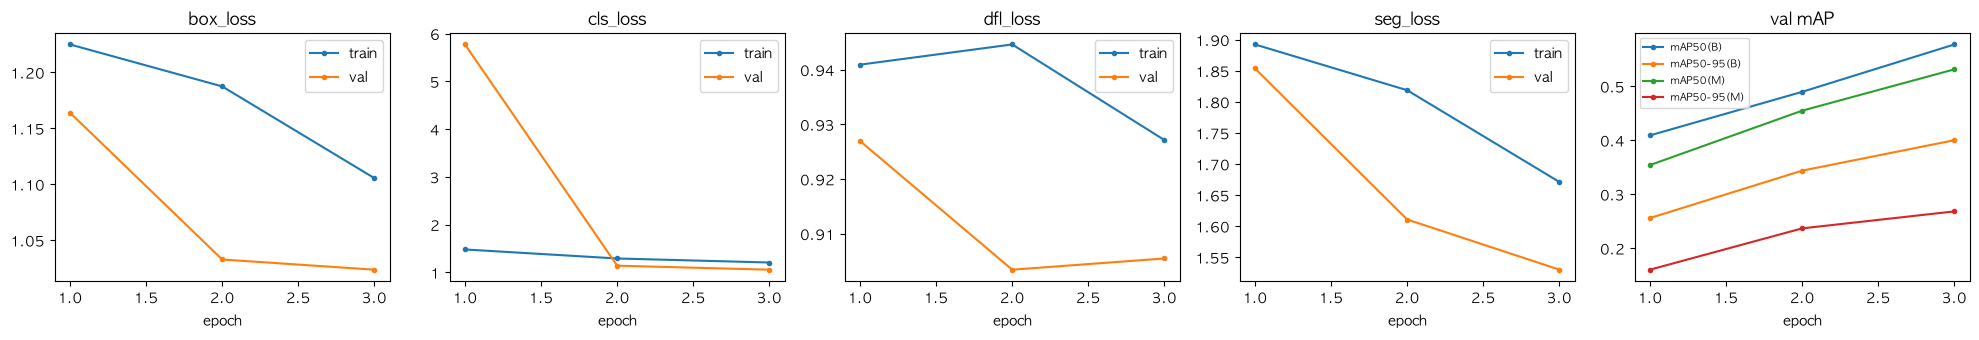

학습한 epoch: 3 / mask mAP50-95 가 가장 높았던 epoch: 3


In [25]:
hist = pd.read_csv(TRAIN_DIR / "results.csv")
hist.columns = [c.strip() for c in hist.columns]

loss_cols   = [c for c in hist.columns if c.endswith("_loss")]
loss_kinds  = sorted({c.split("/")[1] for c in loss_cols if hist[c].abs().sum() > 0})   # 항상 0인 손실은 제외
metric_cols = [c for c in hist.columns if c.startswith("metrics/mAP")]

fig, axes = plt.subplots(1, len(loss_kinds) + 1, figsize=(4 * (len(loss_kinds) + 1), 3.5))
for ax, kind in zip(axes, loss_kinds):
    for split in ["train", "val"]:
        if f"{split}/{kind}" in hist:
            ax.plot(hist["epoch"], hist[f"{split}/{kind}"], marker=".", label=split)
    ax.set_title(kind); ax.set_xlabel("epoch"); ax.legend()
for col in metric_cols:
    axes[-1].plot(hist["epoch"], hist[col], marker=".", label=col.replace("metrics/", ""))
axes[-1].set_title("val mAP"); axes[-1].set_xlabel("epoch"); axes[-1].legend(fontsize=7)
plt.tight_layout(); plt.show()

BEST_EPOCH  = int(hist.loc[hist["metrics/mAP50-95(M)"].idxmax(), "epoch"])
DONE_EPOCHS = int(hist["epoch"].max())
print(f"학습한 epoch: {DONE_EPOCHS} / mask mAP50-95 가 가장 높았던 epoch: {BEST_EPOCH}")

## 5. 성능 평가 (val / test)
| 지표 | 의미 |
|---|---|
| **mAP50-95 (Mask)** | ⭐ 대표 지표. IoU 0.5~0.95 에서 평균낸 마스크 정확도 |
| mAP50 (Mask) | IoU 0.5 기준 (느슨한 기준) |
| mAP50-95 (Box) | 박스 기준 정확도 |
| Precision / Recall | 찾은 것 중 맞은 비율 / 정답 중 찾은 비율 |
| AP (car/bus/truck) | 클래스별 mask mAP50-95 |

> **val** 은 설정을 고를 때 보는 점수, **test** 는 최종 보고용 점수입니다. test 점수를 보고 설정을 고르면 안 됩니다!

Ultralytics 8.4.152 🚀 Python-3.11.15 torch-2.14.0 MPS (Apple M5)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5868.9±2696.0 MB/s, size: 539.1 KB)
val: Scanning /Users/hantaeho/Documents/KDT/machine learning and deep learning/MLDL_project/traffic_data2/car_seg_split/labels/val.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 104.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.1it/s 3.2s0.3s
                   all        100        666      0.617      0.512      0.578        0.4      0.615      0.476      0.531      0.268
Speed: 0.3ms preprocess, 4.5ms inference, 0.0ms loss, 10.9ms postprocess per image
Results saved to /Users/hantaeho/Documents/KDT/machine learning and deep learning/MLDL_project/traffic_data2/car_seg_finetune/runs/한태호_yolov8s-seg_img

,mAP50-95(M),mAP50(M),mAP75(M),mAP50-95(B),mAP50(B),Precision(M),Recall(M),AP_car(M),AP_bus(M),AP_truck(M)
val,0.2681,0.5312,0.2184,0.3999,0.5781,0.6150,0.4756,0.3203,0.2000,0.2840
test,0.2399,0.4680,0.2257,0.3510,0.5009,0.4896,0.4691,0.3760,0.0175,0.3263


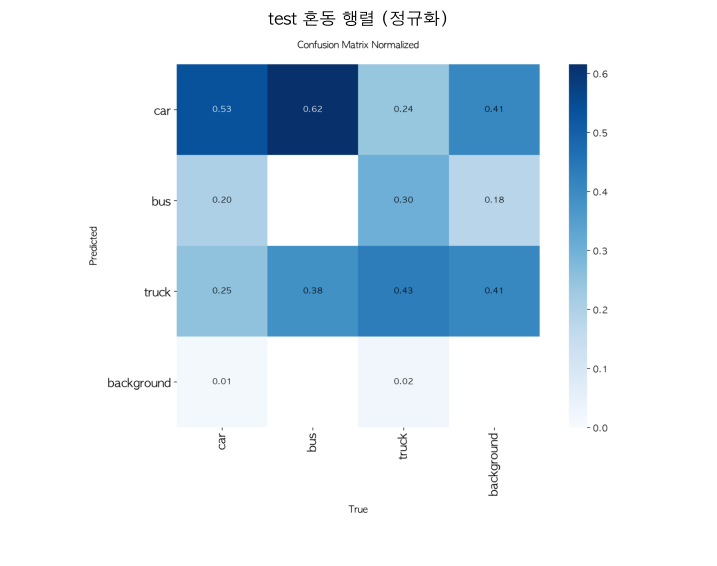

In [26]:
def evaluate(weights, data_yaml, split, name, plots=True):
    m = YOLO(weights).val(
        data=data_yaml, split=split, imgsz=IMGSZ, batch=BATCH, device=DEVICE,
        conf=EVAL_CONF, iou=NMS_IOU, max_det=MAX_DET,
        project=str(EXP_DIR), name=name, exist_ok=True, plots=plots, verbose=False,
    )
    row = {
        "mAP50-95(M)": m.seg.map,  "mAP50(M)": m.seg.map50, "mAP75(M)": m.seg.map75,
        "mAP50-95(B)": m.box.map,  "mAP50(B)": m.box.map50,
        "Precision(M)": m.seg.mp,  "Recall(M)": m.seg.mr,
    }
    for idx, cls_name in CLASS_NAMES.items():
        row[f"AP_{cls_name}(M)"] = float(m.seg.maps[idx])
    free_memory()
    return {k: round(float(v), 4) for k, v in row.items()}

SCORES = {"val": evaluate(BEST_PT, DATA_YAML, "val", "eval_val")}
if EVAL_TEST:
    SCORES["test"] = evaluate(BEST_PT, DATA_YAML, "test", "eval_test")

display(pd.DataFrame(SCORES).T)

# 혼동 행렬: car ↔ truck 을 헷갈리는지, 배경(놓침/오검출)이 많은지 확인
MAIN_SPLIT = "test" if EVAL_TEST else "val"
cm_path = EXP_DIR / f"eval_{MAIN_SPLIT}" / "confusion_matrix_normalized.png"
if cm_path.exists():
    plt.figure(figsize=(9, 7)); plt.imshow(Image.open(cm_path)); plt.axis("off")
    plt.title(f"{MAIN_SPLIT} 혼동 행렬 (정규화)"); plt.show()

## 6. 조건별 성능 🌙🌧️🌉
CCTV 는 **밤 · 비 · 안개 · 터널** 에서도 잘 돼야 합니다. 조건별로 이미지를 나눠 mask mAP 를 따로 계산합니다.
- 전체 mAP 는 비슷해도 **야간 mAP** 에서 모델 차이가 크게 날 수 있습니다.
- `EVAL_BY_CONDITION = False` 면 건너뜁니다.

Ultralytics 8.4.152 🚀 Python-3.11.15 torch-2.14.0 MPS (Apple M5)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8286.2±1895.0 MB/s, size: 476.3 KB)
val: Scanning /Users/hantaeho/Documents/KDT/machine learning and deep learning/MLDL_project/traffic_data2/car_seg_split/labels/test... 75 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 5.1Kit/s 0.0s
val: New cache created: /Users/hantaeho/Documents/KDT/machine learning and deep learning/MLDL_project/traffic_data2/car_seg_split/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.0it/s 2.0s.2s
                   all         75        397      0.506      0.433      0.503      0.349      0.492      0.414      0.462      0.233
Speed: 0.3ms preprocess, 3.8ms inference, 0.0ms loss, 11.1ms postprocess per image
  day_night=day        (  75장)  mask mAP50-95 = 0.2330
  건너뜀: day_night=twilight (13장 < 30)
  건너뜀: day_night=night (12장 < 30)
Ultralytics 8.4.152 🚀 Python-3.11.15 tor

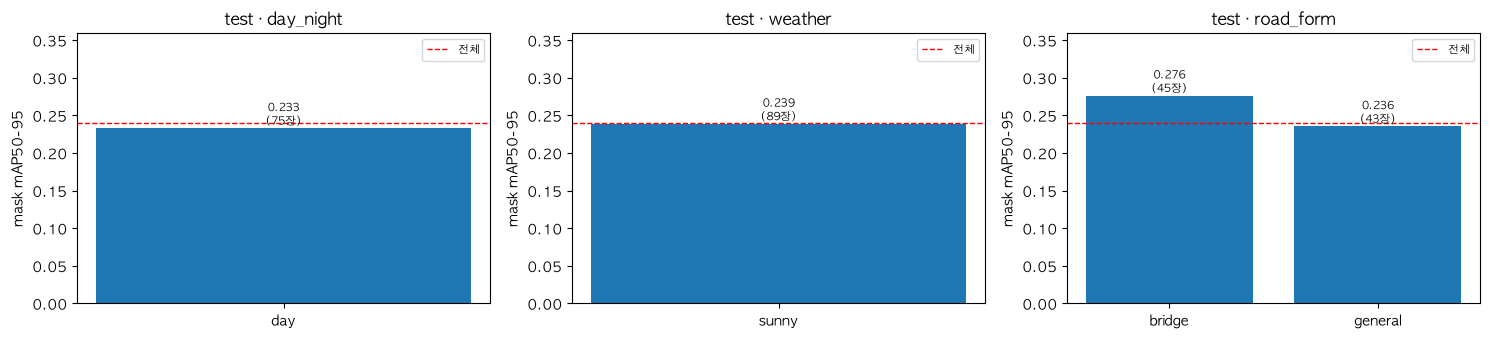

,조건,값,이미지 수,mAP50-95(M),mAP50(M),mAP75(M),mAP50-95(B),mAP50(B),Precision(M),Recall(M),AP_car(M),AP_bus(M),AP_truck(M)
0,day_night,day,75,0.2330,0.4621,0.2183,0.3491,0.5032,0.4915,0.4141,0.3641,0.0090,0.3260
1,weather,sunny,89,0.2389,0.4665,0.2225,0.3472,0.5005,0.4894,0.4727,0.3770,0.0157,0.3239
2,road_form,bridge,45,0.2764,0.5118,0.2593,0.3963,0.5568,0.4612,0.5054,0.4049,0.0164,0.4079
3,road_form,general,43,0.2356,0.4493,0.2328,0.3430,0.4781,0.5357,0.4398,0.3641,0.0314,0.3112


In [27]:
CONDITION_SCORES = []
if EVAL_BY_CONDITION:
    cond_imgs = test_imgs if EVAL_TEST else val_imgs
    cond_info = MANIFEST.loc[[p.name for p in cond_imgs]]
    for cond in CONDITIONS:
        for value, n in cond_info[cond].value_counts().items():
            if n < MIN_GROUP_IMAGES:
                print(f"  건너뜀: {cond}={value} ({n}장 < {MIN_GROUP_IMAGES})")
                continue
            group = [p for p in cond_imgs if MANIFEST.loc[p.name, cond] == value]
            lst = write_list(f"{MAIN_SPLIT}_{cond}={value}", group)
            gyaml = write_data_yaml(LISTS_DIR / f"{MAIN_SPLIT}_{cond}={value}.yaml", lst, lst)
            sc = evaluate(BEST_PT, gyaml, "val", f"eval_{MAIN_SPLIT}_by_condition", plots=False)
            CONDITION_SCORES.append({"조건": cond, "값": value, "이미지 수": len(group), **sc})
            print(f"  {cond}={value:10s} ({len(group):4d}장)  mask mAP50-95 = {sc['mAP50-95(M)']:.4f}")

    cond_df = pd.DataFrame(CONDITION_SCORES)
    cond_df.to_csv(EXP_DIR / "condition_scores.csv", index=False, encoding="utf-8-sig")

    fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(5 * len(CONDITIONS), 3.5))
    for ax, cond in zip(np.atleast_1d(axes), CONDITIONS):
        sub = cond_df[cond_df["조건"] == cond]
        ax.bar(sub["값"].astype(str), sub["mAP50-95(M)"])
        ax.axhline(SCORES[MAIN_SPLIT]["mAP50-95(M)"], color="r", ls="--", lw=1, label="전체")
        for x, (v, n) in enumerate(zip(sub["mAP50-95(M)"], sub["이미지 수"])):
            ax.text(x, v, f"{v:.3f}\n({n}장)", ha="center", va="bottom", fontsize=8)
        ax.set_title(f"{MAIN_SPLIT} · {cond}"); ax.set_ylabel("mask mAP50-95"); ax.legend(fontsize=8)
        ax.set_ylim(0, max(cond_df["mAP50-95(M)"].max() * 1.3, 0.01))
    plt.tight_layout(); plt.show()
    display(cond_df)

## 7. 추론 시간 측정 ⏱️
**이미지 1장씩(batch=1)** 넣었을 때 걸리는 시간 — 실제 CCTV 프레임을 한 장씩 처리하는 상황과 같습니다.
- 디스크 읽기 시간은 빼기 위해 이미지를 먼저 메모리에 올려두고 측정합니다.
- **전체(ms)** = 전처리 + 모델 추론 + 후처리 + 차량 마스크 픽셀 수 계산까지 (점유율 계산에 필요한 전 과정)
- 첫 몇 번은 느리므로 워밍업 후 측정합니다.

측정 이미지 30장 · imgsz 640 · Apple M5 (mps)


,평균(ms),중앙값(ms),p95(ms),FPS,전처리(ms),추론(ms),후처리(ms),파라미터(M),GFLOPs
0,17.51,13.99,21.26,57.1,0.49,5.19,11.28,11.79,40.2


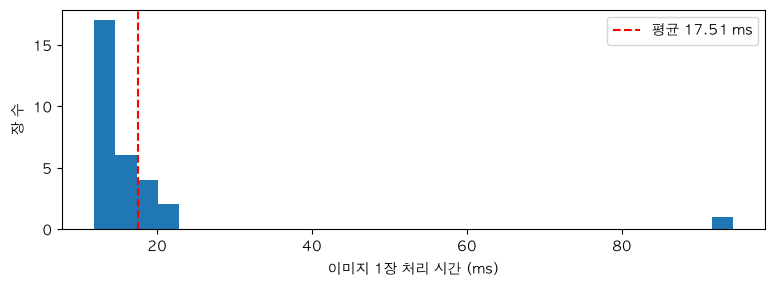

In [28]:
def sync():
    if DEVICE == "mps":
        torch.mps.synchronize()      # GPU 작업이 실제로 끝날 때까지 기다림 (정확한 시간 측정)

def benchmark(weights, image_paths, n=SPEED_N, warmup=SPEED_WARMUP):
    net = YOLO(weights)
    frames = [cv2.imread(str(p)) for p in image_paths[:n]]      # 미리 메모리에 올려둠
    kw = dict(imgsz=IMGSZ, device=DEVICE, conf=PRED_CONF, iou=NMS_IOU, max_det=MAX_DET, verbose=False)

    for f in frames[:warmup]:                                    # 워밍업
        net.predict(f, **kw)

    rows = []
    for f in frames:
        sync(); t0 = time.perf_counter()
        r = net.predict(f, **kw)[0]
        vehicle_px = int(r.masks.data.any(0).sum().item()) if r.masks is not None else 0   # 차량 픽셀 수 (점유율 계산에 쓰는 값)
        sync(); total = (time.perf_counter() - t0) * 1000
        rows.append({"전체(ms)": total, "전처리(ms)": r.speed["preprocess"],
                     "추론(ms)": r.speed["inference"], "후처리(ms)": r.speed["postprocess"]})
    return pd.DataFrame(rows), net

speed_images = pick(test_imgs if test_imgs else val_imgs, SPEED_N, seed=SEED + 2)
speed_df, bench_model = benchmark(BEST_PT, speed_images)

# 모델 크기 (파라미터 수, 연산량)
from ultralytics.utils.torch_utils import get_num_params, get_flops
PARAMS_M = get_num_params(bench_model.model) / 1e6
GFLOPS   = get_flops(bench_model.model, IMGSZ)
del bench_model; free_memory()

SPEED = {
    "평균(ms)":     round(speed_df["전체(ms)"].mean(), 2),
    "중앙값(ms)":   round(speed_df["전체(ms)"].median(), 2),
    "p95(ms)":      round(speed_df["전체(ms)"].quantile(0.95), 2),
    "FPS":          round(1000 / speed_df["전체(ms)"].mean(), 1),
    "전처리(ms)":   round(speed_df["전처리(ms)"].mean(), 2),
    "추론(ms)":     round(speed_df["추론(ms)"].mean(), 2),
    "후처리(ms)":   round(speed_df["후처리(ms)"].mean(), 2),
    "파라미터(M)":  round(PARAMS_M, 2),
    "GFLOPs":       round(GFLOPS, 1),
}
print(f"측정 이미지 {len(speed_df)}장 · imgsz {IMGSZ} · {chip_name()} ({DEVICE})")
display(pd.DataFrame([SPEED]))

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(speed_df["전체(ms)"], bins=30)
ax.axvline(SPEED["평균(ms)"], color="r", ls="--", label=f"평균 {SPEED['평균(ms)']} ms")
ax.set_xlabel("이미지 1장 처리 시간 (ms)"); ax.set_ylabel("장 수"); ax.legend()
plt.tight_layout(); plt.show()

## 8. 프로젝트 지표: 차량 면적 비 오차 🚦
mAP 가 높아도 **점유율(차량 픽셀 수)** 이 잘 맞는지는 따로 확인해야 합니다.
- **정답 면적 비** = 정답 폴리곤(`labels/`)을 칠한 차량 픽셀 수 / 전체 픽셀 수
- **예측 면적 비** = 예측 마스크들을 합친 차량 픽셀 수 / 전체 픽셀 수
- ※ 아직 도로 모델이 없어서 분모는 **이미지 전체**입니다. 도로 모델이 생기면 분모만 도로 픽셀 수로 바꾸면 됩니다.

| 지표 | 의미 |
|---|---|
| 면적비 MAE (%p) | 정답과 예측 면적 비 차이의 평균 (작을수록 좋음) |
| 차량 픽셀 IoU | 차량/배경 두 가지로만 봤을 때 겹침 정도 (클수록 좋음) |

여러 `conf` 값으로 한 번에 계산해서 **점유율 계산에 가장 좋은 conf** 도 찾아봅니다.

이미지 30장 기준


,면적비 MAE(%p),차량 픽셀 IoU,정답 평균 면적비(%),예측 평균 면적비(%)
conf,,,,
0.10,1.498,0.536,2.678,3.595
0.20,0.963,0.622,2.678,2.547
0.25,0.979,0.630,2.678,2.415
0.30,1.029,0.642,2.678,2.294
0.40,0.856,0.677,2.678,2.051
0.50,0.892,0.680,2.678,1.940


PRED_CONF=0.25 → MAE 0.979%p, IoU 0.630 / MAE 가 가장 작은 conf = 0.4


,면적비 MAE(%p),차량 픽셀 IoU,정답 평균 면적비(%),예측 평균 면적비(%),이미지 수
day_night,,,,,
day,0.637,0.631,2.237,2.416,26
night,12.663,0.213,21.216,8.554,1
twilight,0.047,0.757,0.317,0.364,3


,면적비 MAE(%p),차량 픽셀 IoU,정답 평균 면적비(%),예측 평균 면적비(%),이미지 수
weather,,,,,
fog,0.044,0.000,0.044,0.000,1
rainy,2.704,0.297,1.205,3.909,1
snow,0.219,0.781,1.872,2.090,1
sunny,0.978,0.660,2.860,2.461,27


,면적비 MAE(%p),차량 픽셀 IoU,정답 평균 면적비(%),예측 평균 면적비(%),이미지 수
road_form,,,,,
bridge,0.806,0.597,1.838,2.075,15
general,1.527,0.657,4.499,3.154,10
shelter,0.878,0.479,3.984,4.862,1
tunnel,0.282,0.722,0.950,1.232,4


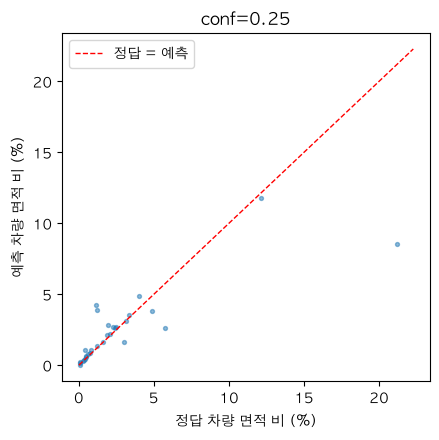

In [29]:
AREA_CONFS  = sorted({0.1, 0.2, 0.3, 0.4, 0.5, PRED_CONF})
area_images = pick(test_imgs if EVAL_TEST else val_imgs, AREA_N, seed=SEED + 3)

def gt_vehicle_mask(img_path, w, h):
    # 정답 폴리곤들을 한 장의 차량 마스크(True/False)로 칠함
    mask = np.zeros((h, w), np.uint8)
    for _, xy in read_polygons(img_path, w, h):
        cv2.fillPoly(mask, [np.round(xy).astype(np.int32)], 1)
    return mask.astype(bool)

net = YOLO(BEST_PT)
records = []
for i, p in enumerate(area_images):
    r = net.predict(str(p), imgsz=IMGSZ, device=DEVICE, conf=min(AREA_CONFS), iou=NMS_IOU,
                    max_det=MAX_DET, retina_masks=True, verbose=False)[0]   # retina_masks: 원본 해상도 마스크
    h, w = r.orig_shape
    gt = gt_vehicle_mask(p, w, h)
    if r.masks is not None:
        masks = r.masks.data.cpu().numpy() > 0.5
        confs = r.boxes.conf.cpu().numpy()
    else:
        masks, confs = np.zeros((0, h, w), bool), np.zeros(0)
    for c in AREA_CONFS:
        keep = confs >= c
        pred = masks[keep].any(0) if keep.any() else np.zeros_like(gt)
        inter, union = (pred & gt).sum(), (pred | gt).sum()
        records.append({"conf": c, "image": p.name,
                        "gt_ratio": gt.mean() * 100, "pred_ratio": pred.mean() * 100,
                        "iou": inter / union if union else 1.0})
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{len(area_images)}")
del net; free_memory()

area_df = pd.DataFrame(records)
area_df["abs_err"] = (area_df["pred_ratio"] - area_df["gt_ratio"]).abs()
AREA_AGG = {"면적비 MAE(%p)": ("abs_err", "mean"), "차량 픽셀 IoU": ("iou", "mean"),
            "정답 평균 면적비(%)": ("gt_ratio", "mean"), "예측 평균 면적비(%)": ("pred_ratio", "mean")}
by_conf = area_df.groupby("conf").agg(**AREA_AGG).round(3)
print(f"이미지 {area_df['image'].nunique()}장 기준")
display(by_conf)

AREA = {
    "면적비 MAE(%p)": float(by_conf.loc[PRED_CONF, "면적비 MAE(%p)"]),
    "차량 픽셀 IoU":  float(by_conf.loc[PRED_CONF, "차량 픽셀 IoU"]),
    "최적 conf(MAE)": float(by_conf["면적비 MAE(%p)"].idxmin()),
}
print(f"PRED_CONF={PRED_CONF} → MAE {AREA['면적비 MAE(%p)']:.3f}%p, IoU {AREA['차량 픽셀 IoU']:.3f} "
      f"/ MAE 가 가장 작은 conf = {AREA['최적 conf(MAE)']}")

# 조건별 면적 비 오차 (PRED_CONF 기준)
sub = area_df[area_df["conf"] == PRED_CONF].join(MANIFEST[CONDITIONS], on="image")
for cond in CONDITIONS:
    display(sub.groupby(cond).agg(**AREA_AGG, **{"이미지 수": ("image", "count")}).round(3))

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(sub["gt_ratio"], sub["pred_ratio"], s=8, alpha=0.5)
lim = max(sub["gt_ratio"].max(), sub["pred_ratio"].max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", lw=1, label="정답 = 예측")
ax.set_xlabel("정답 차량 면적 비 (%)"); ax.set_ylabel("예측 차량 면적 비 (%)")
ax.set_title(f"conf={PRED_CONF}"); ax.legend()
plt.tight_layout(); plt.show()

## 9. 예측 결과 눈으로 보기
왼쪽: 정답 (car=파랑, bus=초록, truck=빨강) / 오른쪽: 모델 예측 (`PRED_CONF` 기준, 색은 Ultralytics 기본 색)
**면적 비 오차가 가장 큰 이미지**들을 보여줍니다 → 모델이 어디서 틀리는지 확인

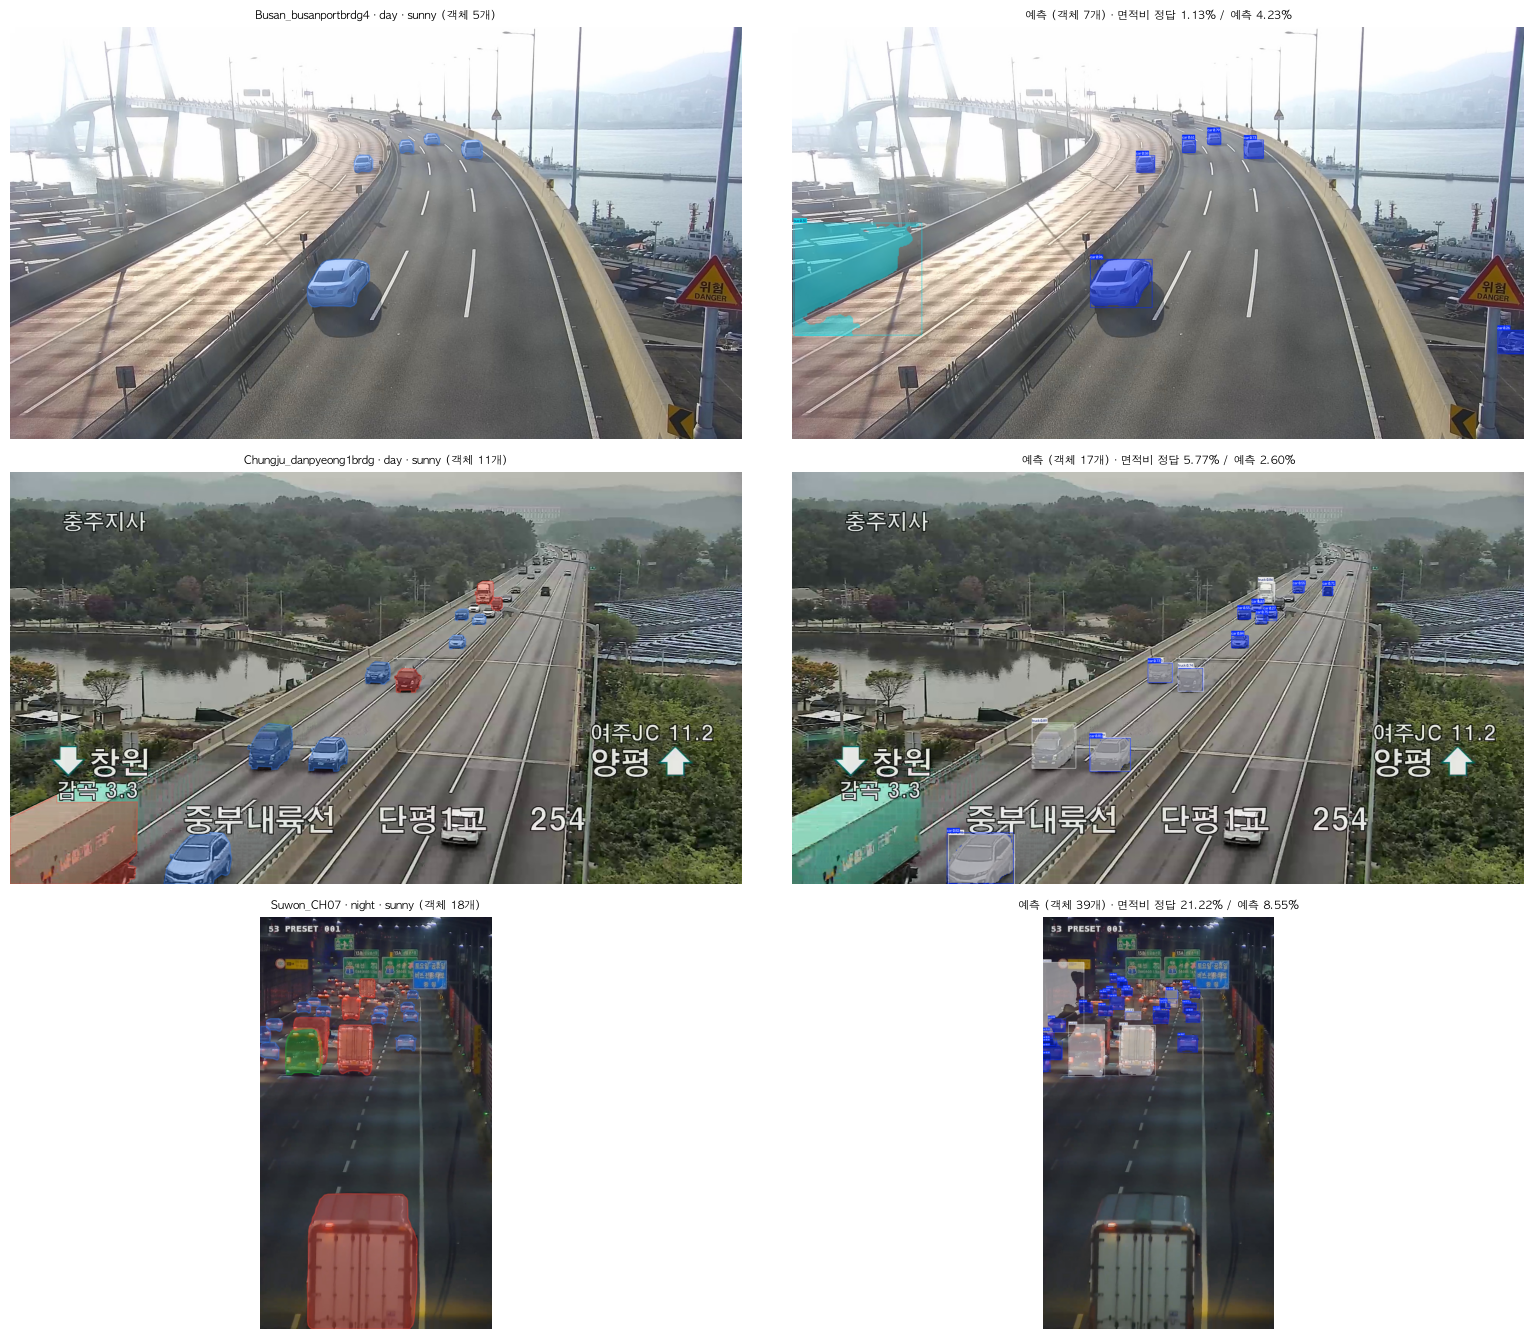

In [30]:
worst = sub.sort_values("abs_err", ascending=False)["image"].head(3).tolist()
show_images = [p for p in area_images if p.name in worst]

net = YOLO(BEST_PT)
fig, axes = plt.subplots(len(show_images), 2, figsize=(16, 4.5 * len(show_images)))
for (ax_gt, ax_pred), p in zip(np.atleast_2d(axes), show_images):
    draw_gt(ax_gt, p)
    r = net.predict(str(p), imgsz=IMGSZ, device=DEVICE, conf=PRED_CONF, iou=NMS_IOU, verbose=False)[0]
    err = sub.set_index("image").loc[p.name]
    ax_pred.imshow(r.plot(line_width=1, font_size=8)[..., ::-1])    # BGR → RGB
    ax_pred.set_title(f"예측 (객체 {len(r.boxes)}개) · 면적비 정답 {err['gt_ratio']:.2f}% / 예측 {err['pred_ratio']:.2f}%",
                      fontsize=8)
    ax_pred.axis("off")
plt.tight_layout(); plt.show()
del net; free_memory()

## 10. 실험 기록표에 저장 📝
`car_seg_finetune/results/<이름>_experiments.csv` 에 이번 실험이 **한 줄 추가**됩니다. (엑셀로 바로 열림)

In [31]:
family, size = MODEL.split("-")[0][:-1], MODEL.split("-")[0][-1]     # "yolo11n-seg" → ("yolo11", "n")

record = {
    # ── 실험 정보
    "실험이름": EXP_NAME, "날짜": STAMP, "담당자": MEMBER, "모델": MODEL, "계열": family, "크기": size,
    "메모": MEMO, "QUICK_TEST": QUICK_TEST, "장치": f"{chip_name()} ({DEVICE})", "ultralytics": ultralytics.__version__,
    # ── 데이터
    "데이터셋": DATA_ROOT.name, "train장수": len(train_imgs), "val장수": len(val_imgs), "test장수": len(test_imgs),
    # ── 학습 설정
    "epochs(설정)": EPOCHS, "epochs(실제)": DONE_EPOCHS, "best_epoch": BEST_EPOCH,
    "time_hours(설정)": TIME_HOURS, "patience": PATIENCE,
    "imgsz": IMGSZ, "batch": BATCH, "pretrained": PRETRAINED, "freeze": FREEZE, "seed": SEED,
    "optimizer": OPTIMIZER, "lr0": LR0, "lrf": LRF, "cos_lr": COS_LR,
    "momentum": MOMENTUM, "weight_decay": WEIGHT_DECAY, "warmup_epochs": WARMUP_EPOCHS,
    "warmup_bias_lr": WARMUP_BIAS_LR, **LOSS, **AUGMENT, **SEG,
    "eval_conf": EVAL_CONF, "nms_iou": NMS_IOU, "pred_conf": PRED_CONF,
    "학습시간(h)": round(TRAIN_HOURS, 2),
}
for split, sc in SCORES.items():                                     # val_mAP50-95(M), test_mAP50-95(M) ...
    record.update({f"{split}_{k}": v for k, v in sc.items()})
for row in CONDITION_SCORES:                                         # test_day_night=night_mAP50-95(M) ...
    record[f"{MAIN_SPLIT}_{row['조건']}={row['값']}_mAP50-95(M)"] = row["mAP50-95(M)"]
record.update({f"속도_{k}": v for k, v in SPEED.items()})
record.update(AREA)
record["best.pt"] = str(BEST_PT)

# 실험 폴더에도 저장
with open(EXP_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(record, f, ensure_ascii=False, indent=2, default=str)

# 내 기록표에 한 줄 추가
LOG_CSV = RESULTS_DIR / f"{MEMBER}_experiments.csv"
log = pd.concat([pd.read_csv(LOG_CSV), pd.DataFrame([record])], ignore_index=True) if LOG_CSV.exists() \
      else pd.DataFrame([record])
log.to_csv(LOG_CSV, index=False, encoding="utf-8-sig")               # utf-8-sig: 엑셀에서 한글 안 깨짐
print(f"✅ 저장: {LOG_CSV}  (총 {len(log)}개 실험)")

pd.DataFrame([record]).T.rename(columns={0: "값"})

✅ 저장: /Users/hantaeho/Documents/KDT/machine learning and deep learning/MLDL_project/traffic_data2/car_seg_finetune/results/한태호_experiments.csv  (총 1개 실험)


,값
실험이름,한태호_yolov8s-seg_img640_20260915-0853_QUICK
날짜,20260915-0853
담당자,한태호
모델,yolov8s-seg
계열,yolov8
...,...
속도_GFLOPs,40.2
면적비 MAE(%p),0.979
차량 픽셀 IoU,0.63
최적 conf(MAE),0.4


## 11. 전체 실험 비교 (6명 결과 모으기) 🏆
팀원들의 `*_experiments.csv` 파일을 **내 `car_seg_finetune/results/` 폴더에 복사**한 뒤 이 셀만 실행하면 됩니다.
(학습 없이 이 셀만 실행해도 됩니다 — `0` 셀만 먼저 실행하세요)

In [ ]:
HIDE_QUICK_TEST = True     # QUICK_TEST 기록은 비교에서 빼기
SORT_BY = "val_mAP50-95(M)"   # 정렬 기준 (설정 고르기는 val 로!)

csvs = sorted(Path("car_seg_finetune/results").glob("*_experiments.csv"))
all_log = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True) if csvs else pd.DataFrame()
if HIDE_QUICK_TEST and len(all_log):
    all_log = all_log[all_log["QUICK_TEST"] != True]
print(f"CSV {len(csvs)}개 · 실험 {len(all_log)}개")

if len(all_log):
    show_cols = ["담당자", "모델", "메모", "imgsz", "batch", "optimizer", "lr0", "epochs(실제)",
                 "val_mAP50-95(M)", "test_mAP50-95(M)", "test_mAP50(M)", "test_mAP50-95(B)",
                 "test_AP_car(M)", "test_AP_bus(M)", "test_AP_truck(M)",
                 "test_day_night=night_mAP50-95(M)", "test_weather=fog_mAP50-95(M)", "test_road_form=tunnel_mAP50-95(M)",
                 "속도_평균(ms)", "속도_FPS", "속도_파라미터(M)", "면적비 MAE(%p)", "차량 픽셀 IoU", "학습시간(h)"]
    board = all_log[[c for c in show_cols if c in all_log]].sort_values(SORT_BY, ascending=False)
    display(board.reset_index(drop=True))

    # 속도 vs 정확도: 왼쪽 위에 있을수록 빠르고 정확한 모델
    score_col = "test_mAP50-95(M)" if all_log.get("test_mAP50-95(M)", pd.Series(dtype=float)).notna().any() else "val_mAP50-95(M)"
    fig, ax = plt.subplots(figsize=(7, 5))
    for model_name, g in all_log.groupby("모델"):
        ax.scatter(g["속도_평균(ms)"], g[score_col], s=60, label=model_name)
    ax.set_xlabel("이미지 1장 처리 시간 (ms)  ← 빠를수록 좋음")
    ax.set_ylabel(f"{score_col}  ↑ 높을수록 좋음")
    ax.set_title("속도 vs 정확도 (왼쪽 위가 좋음)"); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()